In [ ]:
class Curve:
	def __init__(self, Vd, Vm, Va, D, Dd, Da) -> None:
		# We split the movement in 3 phases: departure, max speed, arrival

		self.Vd = Vd
		self.Vm = Vm
		self.Va = Va

		self.D = D
		self.Dd = Dd
		self.Da = Da
		self.Dm = self.D - self.Dd - self.Da

		self.Td = 2 * self.Dd / (self.Vd + self.Vm)  # total time of departure phase
		self.Ta = 2 * self.Da / (self.Va + self.Vm)  # total time of arrival phase
		self.Tm = self.Dm / self.Vm

		self.T = self.Td + self.Tm + self.Ta

		self.Cd = (self.Vm - self.Vd) / self.Td  # Departure phase slope
		self.Ca = (self.Va - self.Vm) / self.Ta  # Arrival phase slope

	def V1(self,t):
		return self.Vd + self.Cd * t  # Velocity on departure phase equation
	def V2(self,t):
		return self.Vm  # Velocity on max speed phase equation
	def V3(self,t):
		return self.Va + self.Ca * (t - self.T)  # Velocity on arrival phase equation

	def PlannedVelocity(self, t):
		if t<self.T:
			return min(self.V1(t), self.V2(t), self.V3(t))
		else:
			return self.Va

	def PlannedTotalTime(self):
		return self.T

	def PlannedPosition(self, t):
     	# Phase 1: Departure
		if t <= self.Td:  
			return self.Vd * t + 0.5 * self.Cd * t ** 2
		# Phase 2: Max speed
		elif t <= self.Td + self.Tm:  
			t_m = t - self.Td
			return self.Dd + self.Vm * t_m
		# Phase 3: Arrival
		elif t <= self.T:  
			t_a = t - self.Td - self.Tm
			return self.Dd + self.Dm + self.Vm * t_a + 0.5 * self.Ca * t_a ** 2
		# After planned time, position remains at final distance D
		else:  
			return self.D

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def test_function(Vd, Vm, Va, D, Dd, Da, endVal=1000, num=10000):
    T = np.linspace(0, endVal, num)
    curve = Curve(Vd, Vm, Va, D, Dd, Da)
    y_velocity = np.array([curve.PlannedVelocity(t) for t in T])
    y_position = np.array([curve.PlannedPosition(t) for t in T])
    
    end_index = np.searchsorted(T, curve.PlannedTotalTime(), side='left')
    
    print("Total distance:", np.trapz(y_velocity[:end_index], T[:end_index]))
    
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Axe gauche pour la position
    ax1.plot(T[:end_index], y_position[:end_index], color='b', label="y = position(t)")
    ax1.set_xlabel("t")
    ax1.set_ylabel("Position", color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # Axe droit pour la vitesse
    ax2 = ax1.twinx()
    ax2.plot(T[:end_index], y_velocity[:end_index], color='r', label="y = velocity(t)")
    ax2.set_ylabel("Velocity", color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    fig.tight_layout()  # Pour éviter le chevauchement des labels
    plt.title("Plot of Position and Velocity by Time")
    plt.grid(True)
    plt.show()
    
    return np.trapz(y_velocity[:end_index], T[:end_index])


Total distance: 999.9989147829674


C:\Users\floot\AppData\Local\Temp\ipykernel_5848\1611861375.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print("Total distance:", np.trapz(y_velocity[:end_index], T[:end_index]))


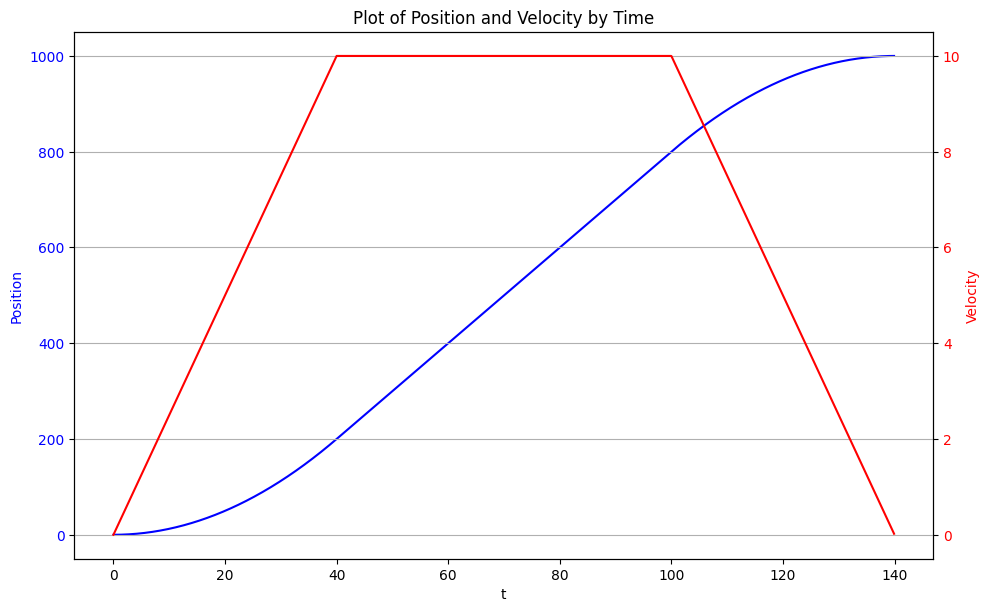

C:\Users\floot\AppData\Local\Temp\ipykernel_5848\1611861375.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_velocity[:end_index], T[:end_index])


Total distance: 999.9978145629344


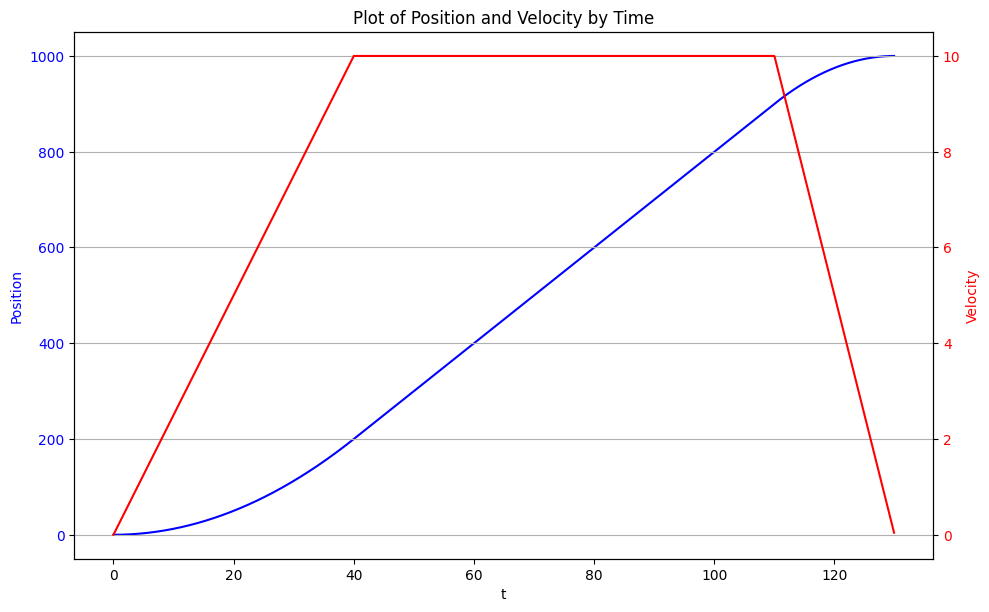

Total distance: 999.9992731879781


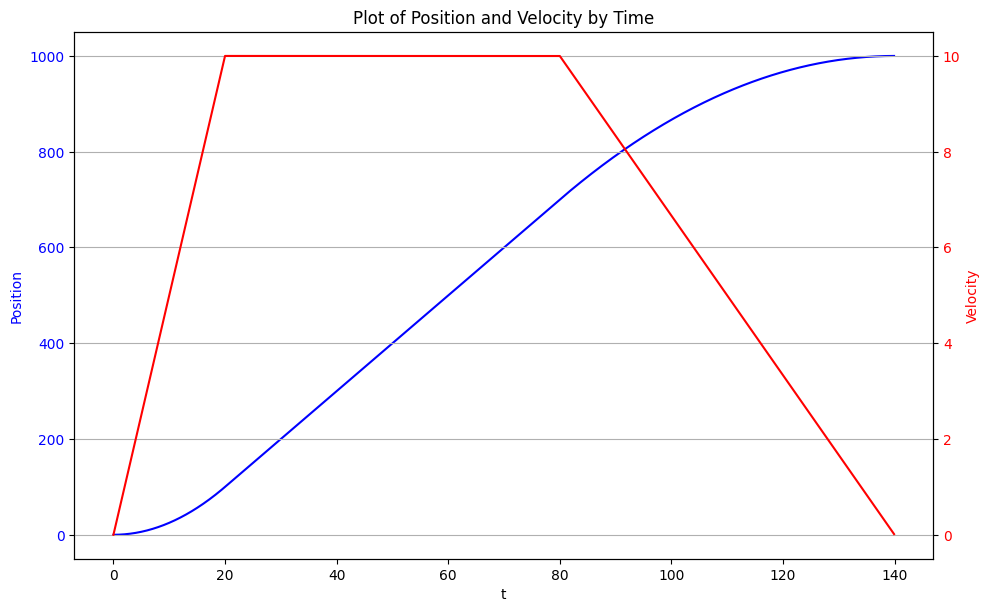

Total distance: 999.9990148029704


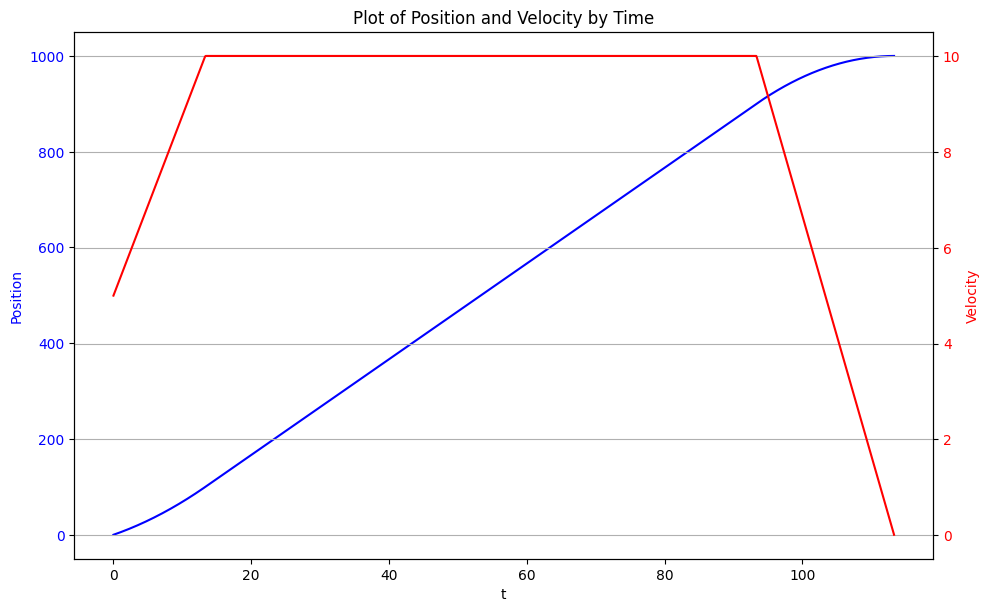

Total distance: 999.8896804371905


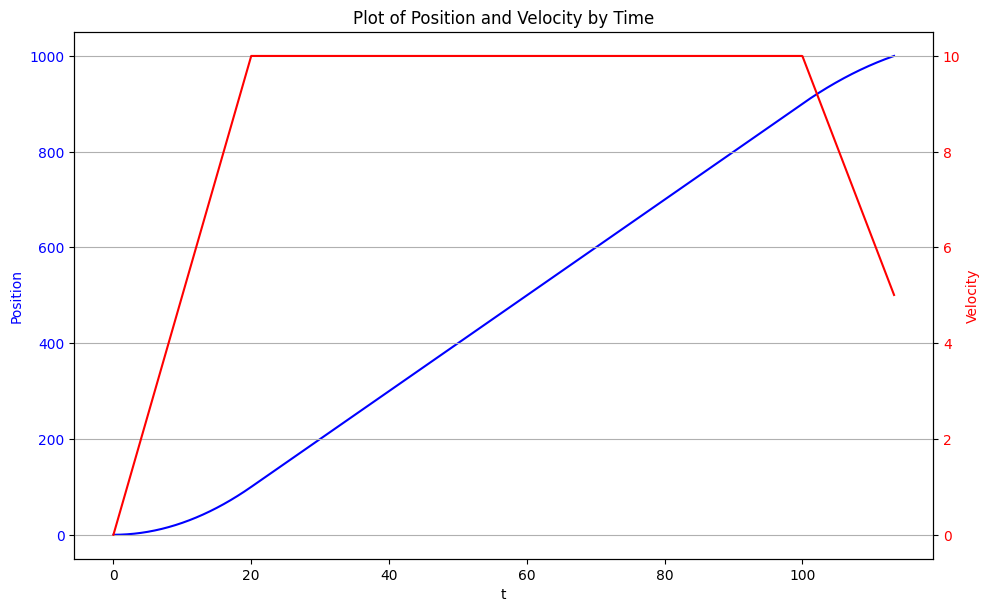

Total distance: 999.7186337295593


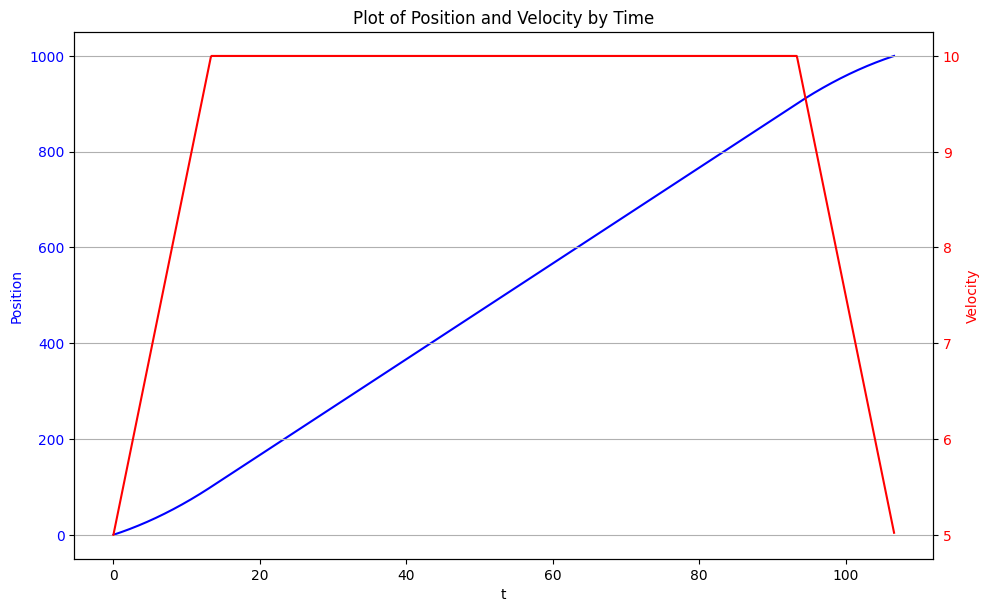

Total distance: 1539.75098980045


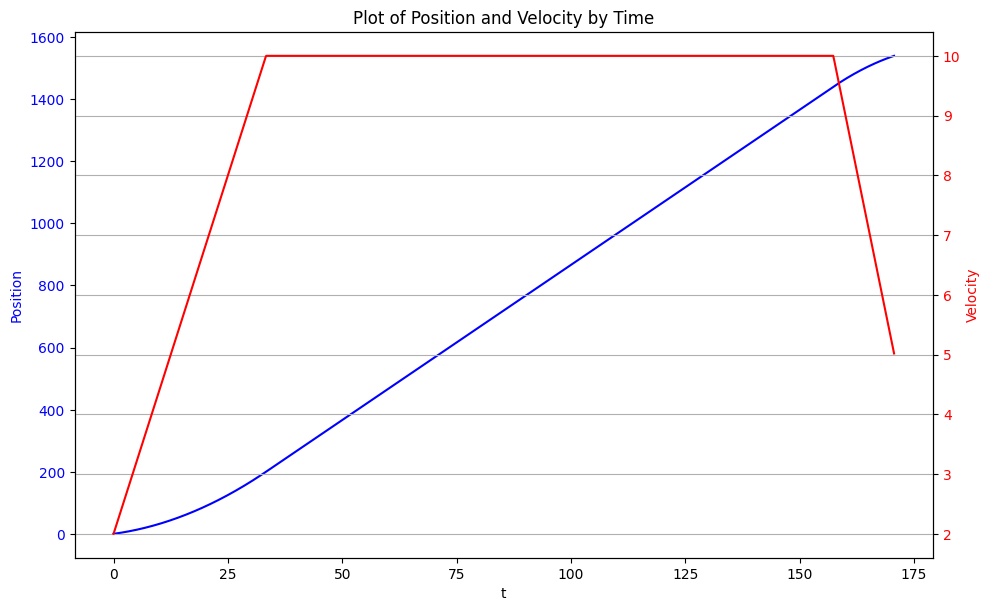

In [13]:
assert round(test_function(0, 10, 0, 1000, 200, 200)/10)==100, "test1"
assert round(test_function(0, 10, 0, 1000, 200, 100)/10)==100, "test2"
assert round(test_function(0, 10, 0, 1000, 100, 300)/10)==100, "test3"
assert round(test_function(5, 10, 0, 1000, 100, 100)/10)==100, "test4"
assert round(test_function(0, 10, 5, 1000, 100, 100)/10)==100, "test5"
assert round(test_function(5, 10, 5, 1000, 100, 100)/10)==100, "test5"
assert round(test_function(2, 10, 5, 1540, 200, 100)/10)==1540/10, "test5"


Note: Doesn't work if absurd values

Total distance: 110.033768153293


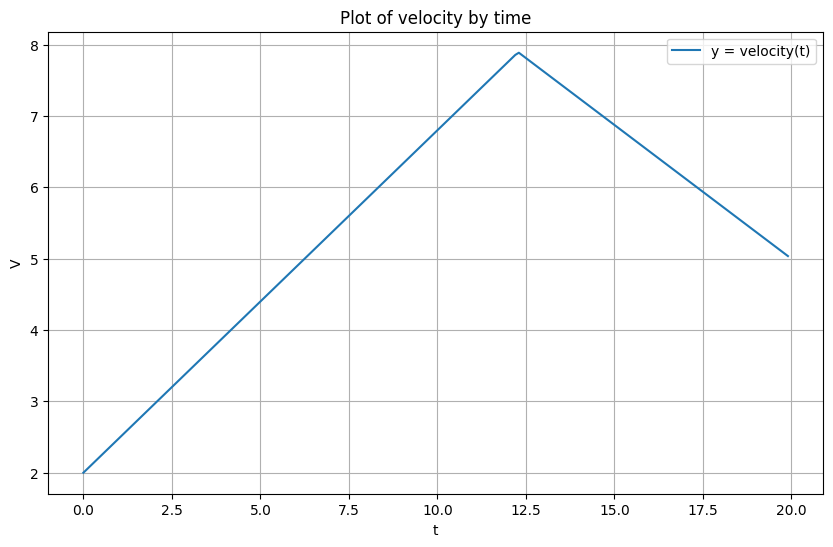

110.033768153293

In [22]:
test_function(2, 10, 5, 100, 100, 100)

# Test result from C++

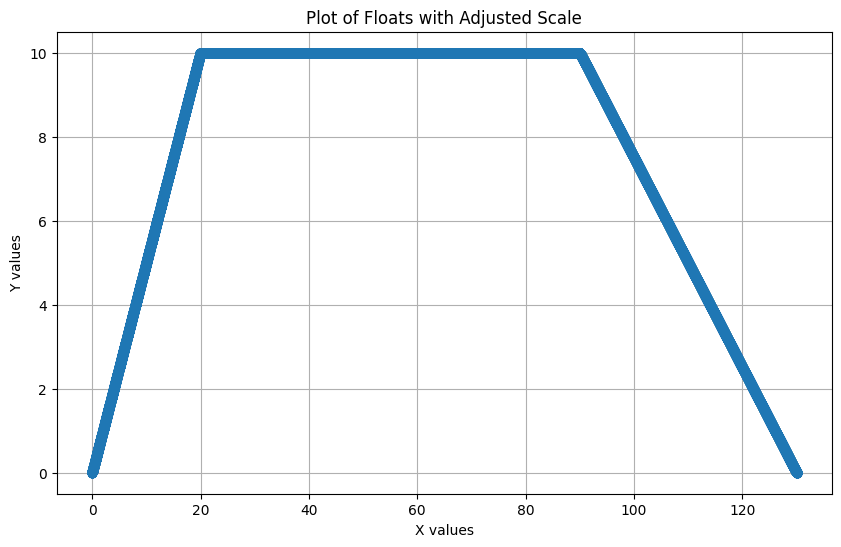

Total distance: 1000.1537539492323


In [24]:
import matplotlib.pyplot as plt

# Function to read and parse the file
def read_and_parse_file(file_path):
	with open(file_path, 'r') as file:
		lines = file.readlines()

	# First line contains floats separated by commas
	y_values = list(map(float, lines[0].strip().split(',')))

	# Second line contains a single float
	x_max = float(lines[1].strip())

	return y_values, x_max

# Function to generate x values and plot the graph
def plot_graph(y_values, x_max):
	# Generate x values from 0 to x_max with the same number of points as y_values
	x_values = [i * (x_max / (len(y_values) - 1)) for i in range(len(y_values))]

	# Plotting the graph
	plt.figure(figsize=(10, 6))
	plt.plot(x_values, y_values, marker='o')
	plt.title('Plot of Floats with Adjusted Scale')
	plt.xlabel('X values')
	plt.ylabel('Y values')
	plt.grid(True)
	plt.show()
	print("Total distance:", np.trapz(y_values,x_values))

# File path to the input file
file_path = 'out.txt'

# Read and parse the file
y_values, x_max = read_and_parse_file(file_path)

# Plot the graph
plot_graph(y_values, x_max)
